# EDA de Turnover | People Analytics

## Objetivo da análise

Este projeto tem como objetivo explorar os fatores associados ao turnover de colaboradores utilizando dados de People Analytics.

A análise combina SQL e Python para investigar padrões relacionados a tempo de empresa, renda, horas extras, satisfação, nível hierárquico, idade, 
distância de casa e outros fatores.

Nesta etapa, os dados são carregados diretamente de um banco PostgreSQL para um DataFrame em Python, onde será realizada a Análise Exploratória de 
Dados (EDA).

### Principais etapas

- validação e qualidade dos dados
- estatísticas descritivas
- análise de distribuição das variáveis
- comparação entre colaboradores que permaneceram e saíram
- análise de possíveis fatores associados ao turnover
- visualizações e identificação de padrões

**Tecnologias**: PostgreSQL, SQL, Python, pandas, matplotlib, statsmodels e Jupyter Notebook.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

## 2. Conexão com o PostgreSQL

In [4]:
from getpass import getpass
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

usuario = "postgres"
senha = getpass("Digite a senha do PostgreSQL: ")
host = "localhost"
porta = 5432
banco = "people_analytics"

url = URL.create(
    drivername="postgresql+psycopg2",
    username=usuario,
    password=senha,
    host=host,
    port=porta,
    database=banco
)

engine = create_engine(url)

Digite a senha do PostgreSQL:  ········


In [5]:
from sqlalchemy import text

with engine.connect() as conexao:
    resultado = conexao.execute(text("SELECT 1"))
    print(resultado.scalar())

1


## 3. Carregamento dos dados

In [6]:
query = """
SELECT *
FROM hr_employee_attrition;
"""

df = pd.read_sql(query, engine)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 4. Validação e qualidade dos dados

In [7]:
df.shape

(1470, 35)

In [9]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [13]:
df_eda = df.drop(
    columns=[
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

In [14]:
df_eda.shape

(1470, 32)

In [15]:
df_eda.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [16]:
df_eda.duplicated().sum()

np.int64(0)

## 5. Visão geral do turnover

In [24]:
df_eda["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [19]:
df_eda["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

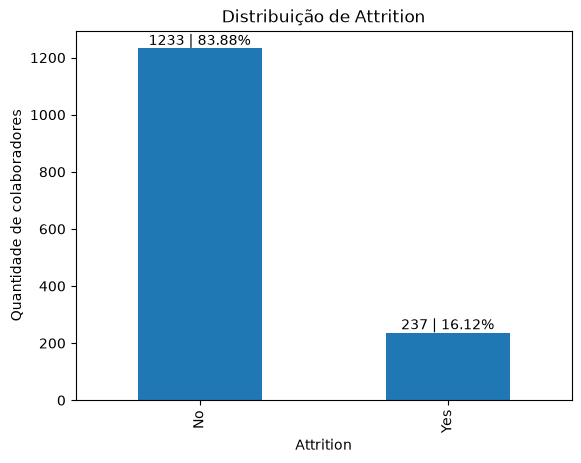

In [22]:
attrition_counts = df_eda["Attrition"].value_counts()
attrition_percent = df_eda["Attrition"].value_counts(normalize=True) * 100

ax = attrition_counts.plot(
    kind="bar",
    title="Distribuição de Attrition"
)

plt.xlabel("Attrition")
plt.ylabel("Quantidade de colaboradores")

for i, valor in enumerate(attrition_counts):
    percentual = attrition_percent.iloc[i]

    ax.text(
        i,
        valor,
        f"{valor} | {percentual:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

## 6. Perfil dos desligamentos

Nesta etapa, serão analisados os principais fatores associados ao turnover, comparando as taxas de desligamento entre diferentes grupos de colaboradores.

A análise começa pela distribuição do turnover entre departamentos e, em seguida, avança para cargo, tempo de empresa, horas extras, renda, idade e indicadores de satisfação.

### 6.1 Turnover por departamento

In [31]:
turnover_departamento = (
    df_eda.groupby("Department")
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_departamento["turnover_percentual"] = (
    turnover_departamento["desligamentos"]
    / turnover_departamento["total_colaboradores"]
    * 100
).round(2)

turnover_departamento = turnover_departamento.sort_values(
    "turnover_percentual",
    ascending=False
)

turnover_departamento

,total_colaboradores,desligamentos,turnover_percentual
Department,,,
Sales,446,92,20.63
Human Resources,63,12,19.05
Research & Development,961,133,13.84


### 6.2 Turnover por cargo

In [34]:
turnover_cargo = (
    df_eda.groupby("JobRole")
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_cargo["turnover_percentual"] = (
    turnover_cargo["desligamentos"]
    / turnover_cargo["total_colaboradores"]
    * 100
).round(2)

turnover_cargo = turnover_cargo.sort_values(
    "turnover_percentual",
    ascending=False
)

turnover_cargo

,total_colaboradores,desligamentos,turnover_percentual
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50


### 6.3 Turnover por tempo de empresa

In [35]:
df_eda["faixa_tempo_empresa"] = pd.cut(
    df_eda["YearsAtCompany"],
    bins=[-1, 1, 3, 5, 10, float("inf")],
    labels=[
        "0 a 1 ano",
        "2 a 3 anos",
        "4 a 5 anos",
        "6 a 10 anos",
        "Mais de 10 anos"
    ]
)

turnover_tempo_empresa = (
    df_eda.groupby("faixa_tempo_empresa", observed=False)
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_tempo_empresa["turnover_percentual"] = (
    turnover_tempo_empresa["desligamentos"]
    / turnover_tempo_empresa["total_colaboradores"]
    * 100
).round(2)

turnover_tempo_empresa

,total_colaboradores,desligamentos,turnover_percentual
faixa_tempo_empresa,,,
0 a 1 ano,215,75,34.88
2 a 3 anos,255,47,18.43
4 a 5 anos,306,40,13.07
6 a 10 anos,448,55,12.28
Mais de 10 anos,246,20,8.13


### 6.4 Turnover por hora extra

In [36]:
turnover_hora_extra = (
    df_eda.groupby("OverTime")
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_hora_extra["turnover_percentual"] = (
    turnover_hora_extra["desligamentos"]
    / turnover_hora_extra["total_colaboradores"]
    * 100
).round(2)

turnover_hora_extra = turnover_hora_extra.sort_values(
    "turnover_percentual",
    ascending=False
)

turnover_hora_extra

,total_colaboradores,desligamentos,turnover_percentual
OverTime,,,
Yes,416,127,30.53
No,1054,110,10.44


### 6.5 Turnover por renda mensal

In [37]:
df_eda["faixa_renda_mensal"] = pd.cut(
    df_eda["MonthlyIncome"],
    bins=[0, 3000, 6000, 10000, 15000, float("inf")],
    labels=[
        "Até 3.000",
        "3.001 a 6.000",
        "6.001 a 10.000",
        "10.001 a 15.000",
        "Acima de 15.000"
    ]
)

turnover_renda = (
    df_eda.groupby("faixa_renda_mensal", observed=False)
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_renda["turnover_percentual"] = (
    turnover_renda["desligamentos"]
    / turnover_renda["total_colaboradores"]
    * 100
).round(2)

turnover_renda

,total_colaboradores,desligamentos,turnover_percentual
faixa_renda_mensal,,,
Até 3.000,395,113,28.61
3.001 a 6.000,519,66,12.72
6.001 a 10.000,275,33,12.00
10.001 a 15.000,148,20,13.51
Acima de 15.000,133,5,3.76


### 6.6 Turnover por idade

In [38]:
df_eda["faixa_etaria"] = pd.cut(
    df_eda["Age"],
    bins=[0, 25, 35, 45, 55, float("inf")],
    labels=[
        "Até 25 anos",
        "26 a 35 anos",
        "36 a 45 anos",
        "46 a 55 anos",
        "Acima de 55 anos"
    ]
)

turnover_idade = (
    df_eda.groupby("faixa_etaria", observed=False)
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_idade["turnover_percentual"] = (
    turnover_idade["desligamentos"]
    / turnover_idade["total_colaboradores"]
    * 100
).round(2)

turnover_idade

,total_colaboradores,desligamentos,turnover_percentual
faixa_etaria,,,
Até 25 anos,123,44,35.77
26 a 35 anos,606,116,19.14
36 a 45 anos,468,43,9.19
46 a 55 anos,226,26,11.50
Acima de 55 anos,47,8,17.02


### 6.7 Turnover por distância de casa

In [39]:
df_eda["faixa_distancia"] = pd.cut(
    df_eda["DistanceFromHome"],
    bins=[0, 5, 10, 20, float("inf")],
    labels=[
        "Até 5",
        "6 a 10",
        "11 a 20",
        "Acima de 20"
    ]
)

turnover_distancia = (
    df_eda.groupby("faixa_distancia", observed=False)
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_distancia["turnover_percentual"] = (
    turnover_distancia["desligamentos"]
    / turnover_distancia["total_colaboradores"]
    * 100
).round(2)

turnover_distancia

,total_colaboradores,desligamentos,turnover_percentual
faixa_distancia,,,
Até 5,632,87,13.77
6 a 10,394,57,14.47
11 a 20,240,48,20.00
Acima de 20,204,45,22.06


### 6.8 Turnover por JobLevel

In [40]:
turnover_joblevel = (
    df_eda.groupby("JobLevel")
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_joblevel["turnover_percentual"] = (
    turnover_joblevel["desligamentos"]
    / turnover_joblevel["total_colaboradores"]
    * 100
).round(2)

turnover_joblevel = turnover_joblevel.sort_values(
    "turnover_percentual",
    ascending=False
)

turnover_joblevel

,total_colaboradores,desligamentos,turnover_percentual
JobLevel,,,
1,543,143,26.34
3,218,32,14.68
2,534,52,9.74
5,69,5,7.25
4,106,5,4.72


### 6.9 Turnover por JobSatisfaction

In [41]:
turnover_job_satisfaction = (
    df_eda.groupby("JobSatisfaction")
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_job_satisfaction["turnover_percentual"] = (
    turnover_job_satisfaction["desligamentos"]
    / turnover_job_satisfaction["total_colaboradores"]
    * 100
).round(2)

turnover_job_satisfaction

,total_colaboradores,desligamentos,turnover_percentual
JobSatisfaction,,,
1,289,66,22.84
2,280,46,16.43
3,442,73,16.52
4,459,52,11.33


### 6.10 Turnover por EnvironmentSatisfaction

In [42]:
turnover_environment = (
    df_eda.groupby("EnvironmentSatisfaction")
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_environment["turnover_percentual"] = (
    turnover_environment["desligamentos"]
    / turnover_environment["total_colaboradores"]
    * 100
).round(2)

turnover_environment

,total_colaboradores,desligamentos,turnover_percentual
EnvironmentSatisfaction,,,
1,284,72,25.35
2,287,43,14.98
3,453,62,13.69
4,446,60,13.45


### 6.11 Turnover por WorkLifeBalance

In [43]:
turnover_worklife = (
    df_eda.groupby("WorkLifeBalance")
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
)

turnover_worklife["turnover_percentual"] = (
    turnover_worklife["desligamentos"]
    / turnover_worklife["total_colaboradores"]
    * 100
).round(2)

turnover_worklife

,total_colaboradores,desligamentos,turnover_percentual
WorkLifeBalance,,,
1,80,25,31.25
2,344,58,16.86
3,893,127,14.22
4,153,27,17.65


## 7. Análises cruzadas

Nesta etapa, os fatores que apresentaram maior associação com o turnover nas análises individuais são combinados para identificar grupos de maior exposição.

Os cruzamentos ajudam a verificar como diferentes características se comportam em conjunto, evitando conclusões baseadas em uma única variável.

### 7.1 Tempo de empresa e horas extras

A análise compara o turnover por faixa de tempo de empresa, separando colaboradores que realizam ou não horas extras.

In [48]:
cruzamento_tempo_overtime = (
    df_eda.groupby(
        ["faixa_tempo_empresa", "OverTime"],
        observed=False
    )
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

cruzamento_tempo_overtime["turnover_percentual"] = (
    cruzamento_tempo_overtime["desligamentos"]
    / cruzamento_tempo_overtime["total_colaboradores"]
    * 100
).round(2)

cruzamento_tempo_overtime

,faixa_tempo_empresa,OverTime,total_colaboradores,desligamentos,turnover_percentual
0,0 a 1 ano,No,146,37,25.34
1,0 a 1 ano,Yes,69,38,55.07
2,2 a 3 anos,No,180,18,10.00
3,2 a 3 anos,Yes,75,29,38.67
4,4 a 5 anos,No,219,18,8.22
5,4 a 5 anos,Yes,87,22,25.29
6,6 a 10 anos,No,328,24,7.32
7,6 a 10 anos,Yes,120,31,25.83
8,Mais de 10 anos,No,181,13,7.18
9,Mais de 10 anos,Yes,65,7,10.77


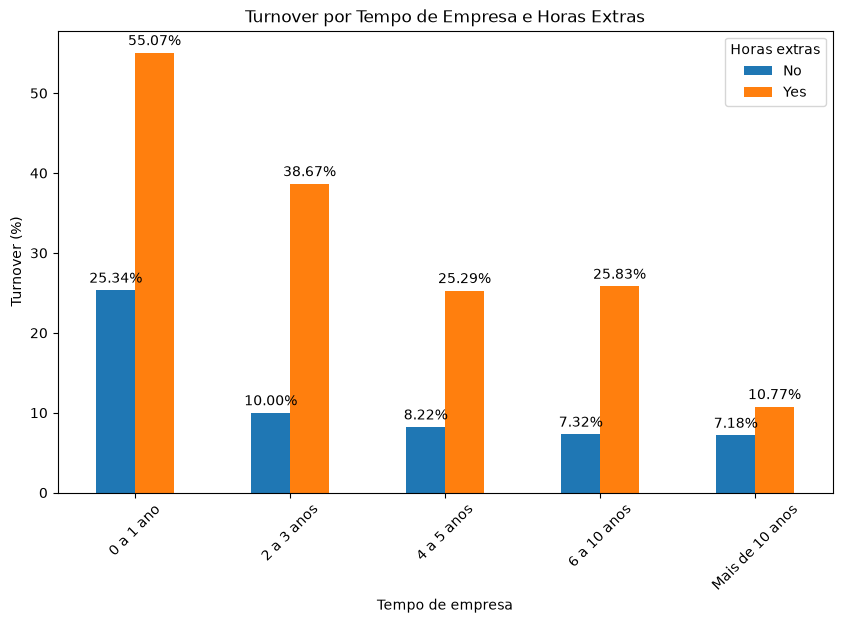

In [49]:
grafico_tempo_overtime = cruzamento_tempo_overtime.pivot(
    index="faixa_tempo_empresa",
    columns="OverTime",
    values="turnover_percentual"
)

ax = grafico_tempo_overtime.plot(
    kind="bar",
    figsize=(10, 6),
    title="Turnover por Tempo de Empresa e Horas Extras"
)

plt.xlabel("Tempo de empresa")
plt.ylabel("Turnover (%)")
plt.xticks(rotation=45)
plt.legend(title="Horas extras")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.show()

### 7.2 Renda mensal e horas extras

A análise verifica como a realização de horas extras se relaciona com o turnover em diferentes faixas de renda mensal.

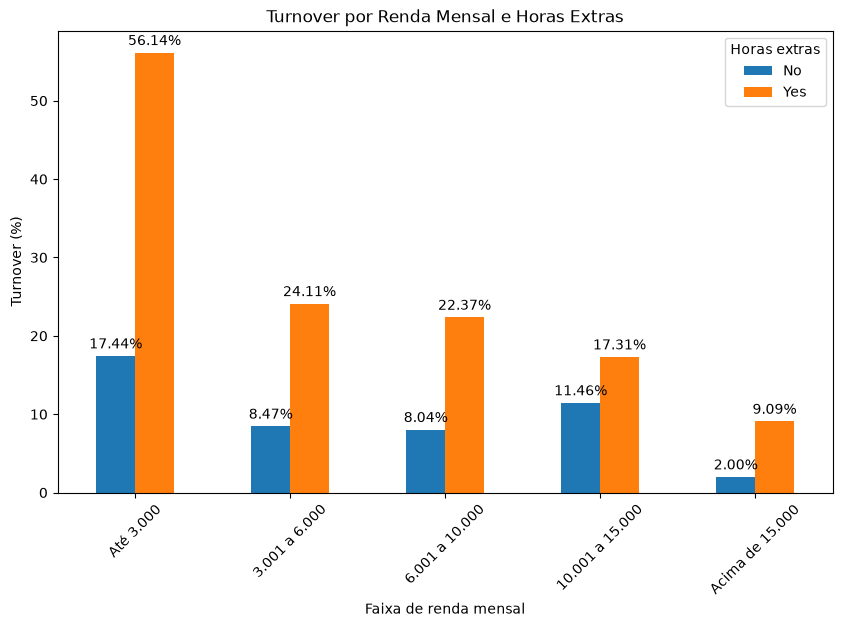

In [50]:
cruzamento_renda_overtime = (
    df_eda.groupby(
        ["faixa_renda_mensal", "OverTime"],
        observed=False
    )
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

cruzamento_renda_overtime["turnover_percentual"] = (
    cruzamento_renda_overtime["desligamentos"]
    / cruzamento_renda_overtime["total_colaboradores"]
    * 100
).round(2)

grafico_renda_overtime = cruzamento_renda_overtime.pivot(
    index="faixa_renda_mensal",
    columns="OverTime",
    values="turnover_percentual"
)

ax = grafico_renda_overtime.plot(
    kind="bar",
    figsize=(10, 6),
    title="Turnover por Renda Mensal e Horas Extras"
)

plt.xlabel("Faixa de renda mensal")
plt.ylabel("Turnover (%)")
plt.xticks(rotation=45)
plt.legend(title="Horas extras")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### 7.3 Idade, renda mensal e horas extras

A análise aprofunda o perfil dos grupos com maior turnover, combinando faixa etária, renda mensal e realização de horas extras.

In [51]:
cruzamento_idade_renda_overtime = (
    df_eda.groupby(
        ["faixa_etaria", "faixa_renda_mensal", "OverTime"],
        observed=False
    )
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

cruzamento_idade_renda_overtime["turnover_percentual"] = (
    cruzamento_idade_renda_overtime["desligamentos"]
    / cruzamento_idade_renda_overtime["total_colaboradores"]
    * 100
).round(2)

cruzamento_idade_renda_overtime

,faixa_etaria,faixa_renda_mensal,OverTime,total_colaboradores,desligamentos,turnover_percentual
0,Até 25 anos,Até 3.000,No,52,15,28.85
1,Até 25 anos,Até 3.000,Yes,26,19,73.08
2,Até 25 anos,3.001 a 6.000,No,29,4,13.79
3,Até 25 anos,3.001 a 6.000,Yes,13,6,46.15
4,Até 25 anos,6.001 a 10.000,No,3,0,0.00
5,Até 25 anos,6.001 a 10.000,Yes,0,0,NaN
6,Até 25 anos,10.001 a 15.000,No,0,0,NaN
7,Até 25 anos,10.001 a 15.000,Yes,0,0,NaN
8,Até 25 anos,Acima de 15.000,No,0,0,NaN
9,Até 25 anos,Acima de 15.000,Yes,0,0,NaN


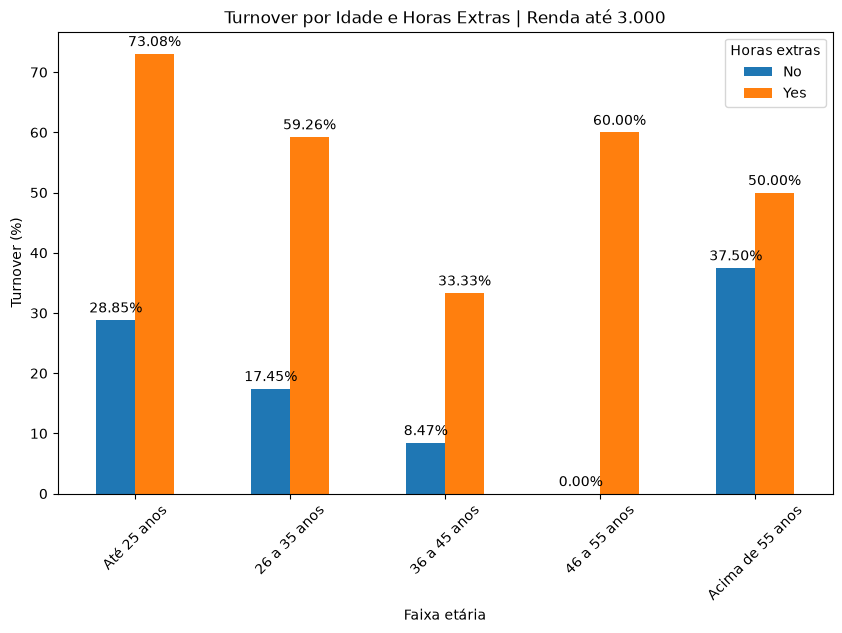

In [52]:
idade_renda_critica = cruzamento_idade_renda_overtime[
    cruzamento_idade_renda_overtime["faixa_renda_mensal"] == "Até 3.000"
]

grafico_idade_renda = idade_renda_critica.pivot(
    index="faixa_etaria",
    columns="OverTime",
    values="turnover_percentual"
)

ax = grafico_idade_renda.plot(
    kind="bar",
    figsize=(10, 6),
    title="Turnover por Idade e Horas Extras | Renda até 3.000"
)

plt.xlabel("Faixa etária")
plt.ylabel("Turnover (%)")
plt.xticks(rotation=45)
plt.legend(title="Horas extras")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### 7.4 Nível hierárquico, renda e horas extras

A análise verifica como nível hierárquico, renda e horas extras se combinam nos grupos com maior turnover.

In [55]:
cruzamento_joblevel_renda_overtime = (
    df_eda.groupby(
        ["JobLevel", "faixa_renda_mensal", "OverTime"],
        observed=True
    )
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

cruzamento_joblevel_renda_overtime["turnover_percentual"] = (
    cruzamento_joblevel_renda_overtime["desligamentos"]
    / cruzamento_joblevel_renda_overtime["total_colaboradores"]
    * 100
).round(2)

cruzamento_joblevel_renda_overtime

,JobLevel,faixa_renda_mensal,OverTime,total_colaboradores,desligamentos,turnover_percentual
0,1,Até 3.000,No,271,48,17.71
1,1,Até 3.000,Yes,110,64,58.18
2,1,3.001 a 6.000,No,116,13,11.21
3,1,3.001 a 6.000,Yes,46,18,39.13
4,2,Até 3.000,No,10,1,10.00
5,2,Até 3.000,Yes,4,0,0.00
6,2,3.001 a 6.000,No,261,19,7.28
7,2,3.001 a 6.000,Yes,94,15,15.96
8,2,6.001 a 10.000,No,117,6,5.13
9,2,6.001 a 10.000,Yes,48,11,22.92


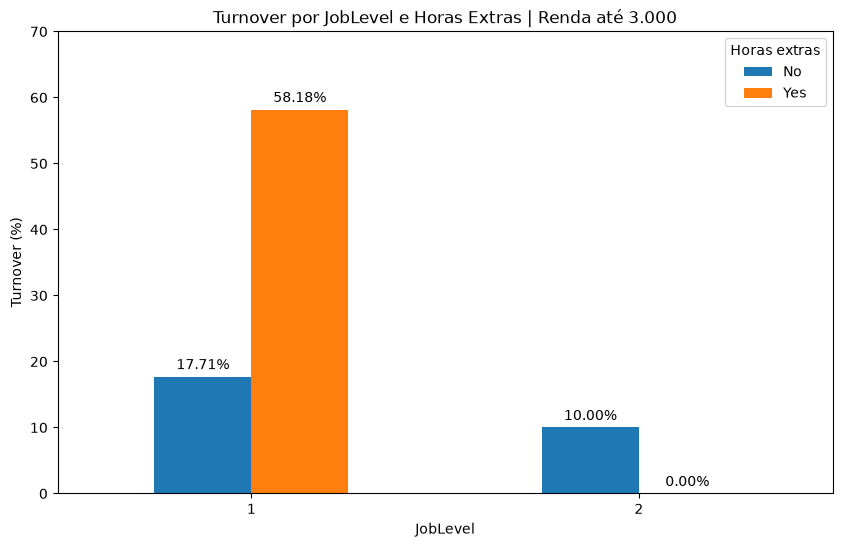

In [69]:
joblevel_renda_critica = cruzamento_joblevel_renda_overtime[
    cruzamento_joblevel_renda_overtime["faixa_renda_mensal"] == "Até 3.000"
]

grafico_joblevel = joblevel_renda_critica.pivot(
    index="JobLevel",
    columns="OverTime",
    values="turnover_percentual"
)

ax = grafico_joblevel.plot(
    kind="bar",
    figsize=(10, 6),
    title="Turnover por JobLevel e Horas Extras | Renda até 3.000"
)

plt.xlabel("JobLevel")
plt.ylabel("Turnover (%)")
plt.xticks(rotation=0)
plt.ylim(0, 70)
plt.legend(title="Horas extras")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.show()

### 7.5 Frequência de viagens e horas extras

A análise compara o turnover entre diferentes frequências de viagens a trabalho, separando colaboradores que realizam ou não horas extras.

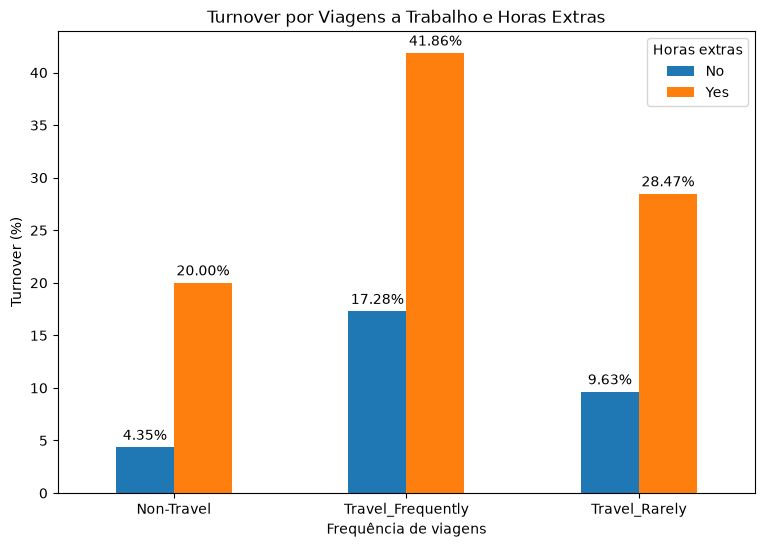

In [56]:
cruzamento_viagem_overtime = (
    df_eda.groupby(
        ["BusinessTravel", "OverTime"]
    )
    .agg(
        total_colaboradores=("Attrition", "size"),
        desligamentos=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

cruzamento_viagem_overtime["turnover_percentual"] = (
    cruzamento_viagem_overtime["desligamentos"]
    / cruzamento_viagem_overtime["total_colaboradores"]
    * 100
).round(2)

grafico_viagem = cruzamento_viagem_overtime.pivot(
    index="BusinessTravel",
    columns="OverTime",
    values="turnover_percentual"
)

ax = grafico_viagem.plot(
    kind="bar",
    figsize=(9, 6),
    title="Turnover por Viagens a Trabalho e Horas Extras"
)

plt.xlabel("Frequência de viagens")
plt.ylabel("Turnover (%)")
plt.xticks(rotation=0)
plt.legend(title="Horas extras")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

## 8. Principais insights

A análise realizada em SQL e Python identificou padrões relevantes
associados ao turnover.

### Principais achados

- O turnover geral da base é de aproximadamente 16,12%.
- Colaboradores com até 1 ano de empresa apresentam taxas de turnover mais elevadas.
- A realização de horas extras aparece de forma recorrente associada a maiores taxas de desligamento.
- Colaboradores mais jovens, principalmente com até 25 anos, apresentaram maior proporção de desligamentos.
- Menores níveis de JobSatisfaction e EnvironmentSatisfaction estiveram associados a maiores taxas de saída.
- Maior distância de casa e maior frequência de viagens também apresentaram associação com maior turnover, principalmente quando 
combinadas com horas extras.

### Perfil de maior exposição

Na análise exploratória, os grupos com maiores taxas de turnover apresentaram principalmente:

- pouco tempo de empresa
- realização de horas extras
- menor renda
- menor nível hierárquico
- idade mais baixa

Nas análises individuais, **menor renda** e **menor nível hierárquico** apresentaram taxas mais elevadas de turnover. 
No entanto, essas associações não permaneceram estatisticamente significativas no modelo multivariado.
Isso indica que esses fatores podem estar relacionados a outras características, como idade, tempo de empresa, horas extras e satisfação.
A análise multivariada apresentada na etapa seguinte permite verificar quais fatores permanecem relevantes quando avaliados simultaneamente.

## 9. Análise multivariada: Regressão Logística

A regressão logística será utilizada para avaliar simultaneamente os principais fatores associados ao desligamento dos colaboradores.

O objetivo é verificar quais variáveis continuam relacionadas ao turnover mesmo quando outros fatores são considerados no mesmo modelo.

In [57]:
df_modelo = df_eda.copy()

df_modelo["AttritionFlag"] = (
    df_modelo["Attrition"] == "Yes"
).astype(int)

In [58]:
df_modelo[["Attrition", "AttritionFlag"]].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [59]:
df_modelo["MonthlyIncome_1000"] = (
    df_modelo["MonthlyIncome"] / 1000
)

In [60]:
import statsmodels.formula.api as smf

modelo = smf.logit(
    formula="""
        AttritionFlag ~
        C(OverTime) +
        YearsAtCompany +
        MonthlyIncome_1000 +
        Age +
        JobLevel +
        JobSatisfaction +
        EnvironmentSatisfaction +
        WorkLifeBalance +
        DistanceFromHome +
        C(BusinessTravel)
    """,
    data=df_modelo
).fit()

print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.362097
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          AttritionFlag   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1458
Method:                           MLE   Df Model:                           11
Date:                Mon, 21 Sep 2026   Pseudo R-squ.:                  0.1802
Time:                        16:02:16   Log-Likelihood:                -532.28
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 6.152e-44
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  1.2654   

In [63]:
import numpy as np

odds_ratio = pd.DataFrame({
    "Odds_Ratio": np.exp(modelo.params),
    "P_Value": modelo.pvalues
})

odds_ratio = odds_ratio.round({
    "Odds_Ratio": 3,
    "P_Value": 4
})

odds_ratio.sort_values(
    "Odds_Ratio",
    ascending=False
)

,Odds_Ratio,P_Value
C(OverTime)[T.Yes],4.711,0.0000
C(BusinessTravel)[T.Travel_Frequently],4.291,0.0000
Intercept,3.544,0.0421
C(BusinessTravel)[T.Travel_Rarely],2.015,0.0360
DistanceFromHome,1.031,0.0010
Age,0.963,0.0003
MonthlyIncome_1000,0.961,0.5024
YearsAtCompany,0.961,0.0385
JobLevel,0.828,0.4354
WorkLifeBalance,0.777,0.0196


## 10. Conclusão e plano de ação

### Conclusão

A análise identificou um turnover geral de 16,12% e mostrou que as maiores taxas de desligamentos aparecem principalmente entre profissionais com 
pouco tempo de empresa, maior exposição a horas extras, viagens frequentes, menor satisfação e pior equilíbrio entre vida pessoal e trabalho.

A regressão logística reforçou esses achados ao considerar vários fatores simultaneamente. 
OverTime foi o fator de maior destaque. O modelo mostrou que colaboradores que realizavam horas extras apresentavam uma tendência de 
desligamento muito maior do que aqueles que não realizavam. Estatisticamente, essa diferença foi de 4,71 vezes na razão de chances de saída.

Viagens frequentes também se destacaram. Colaboradores que viajavam com frequência apresentaram uma tendência de desligamento 
significativamente maior, com uma razão de chances 4,29 vezes superior à dos profissionais que não viajavam.    

A maior distância entre casa e trabalho também esteve associada a uma maior tendência de desligamento.

Por outro lado, maior idade, maior tempo de empresa e melhores níveis de JobSatisfaction, EnvironmentSatisfaction e WorkLifeBalance estiveram 
associados à redução da probabilidade de saída.

Já MonthlyIncome e JobLevel, apesar de apresentarem diferenças nas análises individuais, não permaneceram estatisticamente significativos quando 
os demais fatores foram considerados em conjunto.

### Desfecho

Os resultados indicam que o turnover está mais relacionado à combinação entre carga de trabalho, experiência do colaborador e início da trajetória na 
empresa do que a um único fator isolado.

O principal grupo de atenção envolve profissionais com pouco tempo de empresa expostos a horas extras, especialmente quando também apresentam baixa 
satisfação, pior equilíbrio entre vida pessoal e trabalho ou maior frequência de viagens.

### Plano de ação

**1. Controlar horas extras**  
Monitorar recorrência de OverTime, identificar causas de sobrecarga e avaliar redistribuição de demanda e capacidade das equipes.

**2. Reforçar o acompanhamento no primeiro ano**  
Criar checkpoints em 30, 60, 90, 180 e 365 dias, acompanhando onboarding, satisfação e carga de trabalho.

**3. Revisar viagens frequentes**  
Avaliar frequência de viagens, descanso, WorkLifeBalance e combinação entre viagens e horas extras.

**4. Monitorar satisfação**  
Acompanhar JobSatisfaction, EnvironmentSatisfaction e WorkLifeBalance por área, cargo e liderança.

**5. Avaliar distância de casa**  
Cruzar distância com área, modelo de trabalho e OverTime, avaliando possibilidades de flexibilidade quando aplicável.

**6. Criar monitoramento contínuo**  
Construir um dashboard de People Analytics para acompanhar turnover, horas extras, tempo de empresa, viagens, satisfação e grupos com múltiplos 
fatores de exposição.

> **Objetivo final:** direcionar ações preventivas de retenção para os grupos que apresentam maior exposição ao turnover.